# Geometry-Aware SoftGAN for RadioML BPSK

Implements the SoftGAN training and evaluation pipeline for BPSK IQ data.


## 1. Setup

Import libraries, set the seed, and define the experiment configuration.


In [1]:
# 1. Imports, reproducibility, and experiment configuration

import math
import time
import random
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.parametrizations import spectral_norm

from google.colab import drive

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Data / latent dimensions
# ------------------------------------------------------------
SEQ_LEN = 128

# Total latent size remains 8, but it is split into:
# - global latent: sequence/channel-level variation
# - local latent: time-local symbol/noise variation
GLOBAL_NOISE_DIM = 4
LOCAL_NOISE_DIM = 4
NOISE_DIM = GLOBAL_NOISE_DIM + LOCAL_NOISE_DIM

# ------------------------------------------------------------
# Training hyperparameters
# ------------------------------------------------------------
BATCH_SIZE = 64
TRAIN_STEPS = 12_000

LR_G = 1e-4
LR_D = 5e-5
ADAM_BETAS = (0.0, 0.9)

# The discriminator was too strong in the previous run.
G_UPDATES_PER_STEP = 2

# ------------------------------------------------------------
# Stabilization
# ------------------------------------------------------------
R1_GAMMA = 1.0
R1_INTERVAL = 16

INSTANCE_NOISE_START = 0.03
INSTANCE_NOISE_END_STEP = 6_000

FEATURE_MATCH_WEIGHT = 2.0
PSD_WEIGHT = 0.25

# Constellation-geometry distribution matching.
# The weight is deliberately modest: it should refine the existing
# SoftGAN rather than replace the adversarial objective.
GEOMETRY_MMD_WEIGHT = 0.10
GEOMETRY_WARMUP_STEPS = 1_000

# Geometry contributes to checkpoint selection as well.
GEOMETRY_CHECKPOINT_WEIGHT = 0.25

# ------------------------------------------------------------
# Monitoring
# ------------------------------------------------------------
LOG_EVERY = 100
EVAL_EVERY = 250

# Same normalization as Stage 1
NORM_CLIP = 4.0

print("Device:", device)
print("Batch size:", BATCH_SIZE)
print("Training steps:", TRAIN_STEPS)
print("Generator LR:", LR_G)
print("Discriminator LR:", LR_D)
print("G updates / D update:", G_UPDATES_PER_STEP)
print("Geometry MMD weight:", GEOMETRY_MMD_WEIGHT)

Device: cuda
Batch size: 64
Training steps: 12000
Generator LR: 0.0001
Discriminator LR: 5e-05
G updates / D update: 2
Geometry MMD weight: 0.1


## 2. Load Prepared Data

Load the train, validation, test, and normalization files from Stage 1.


In [2]:
# 2. Load the corrected Stage-1 dataset

drive.mount("/content/drive")

DATA_DIR = Path(
    "/content/drive/MyDrive/GenTWIN_Project/processed/BPSK_snr18"
)

required_files = [
    "X_train.npy",
    "X_val.npy",
    "X_test.npy",
    "train_mean.npy",
    "train_std.npy",
]

missing = [name for name in required_files if not (DATA_DIR / name).exists()]

if missing:
    raise FileNotFoundError(
        "Missing Stage-1 files: "
        + ", ".join(missing)
        + "\nRun the corrected dataset notebook first."
    )

X_train = np.load(DATA_DIR / "X_train.npy").astype(np.float32)
X_val = np.load(DATA_DIR / "X_val.npy").astype(np.float32)
X_test = np.load(DATA_DIR / "X_test.npy").astype(np.float32)

train_mean = np.load(DATA_DIR / "train_mean.npy").astype(np.float32)
train_std = np.load(DATA_DIR / "train_std.npy").astype(np.float32)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)
print("Training samples:", len(X_train))
print("Train mean [I,Q]:", train_mean.reshape(-1))
print("Train std  [I,Q]:", train_std.reshape(-1))

assert X_train.ndim == 3 and X_train.shape[1:] == (2, SEQ_LEN)
assert X_val.ndim == 3 and X_val.shape[1:] == (2, SEQ_LEN)
assert X_test.ndim == 3 and X_test.shape[1:] == (2, SEQ_LEN)
assert np.all(train_std > 0)

Mounted at /content/drive
Train: (800, 2, 128)
Val  : (100, 2, 128)
Test : (100, 2, 128)
Training samples: 800
Train mean [I,Q]: [ 1.5961787e-05 -1.6884846e-05]
Train std  [I,Q]: [0.00529537 0.00661516]


## 3. Normalize IQ Data

Normalize the IQ samples and create the training data loader.


In [3]:
# 3. Normalize IQ data and create data loader

def normalize_iq(x):
    z = (x - train_mean) / train_std
    z = np.clip(z, -NORM_CLIP, NORM_CLIP)
    return (z / NORM_CLIP).astype(np.float32)


def denormalize_iq(x_seq):
    mean_seq = train_mean.reshape(1, 1, 2)
    std_seq = train_std.reshape(1, 1, 2)
    return (x_seq * NORM_CLIP) * std_seq + mean_seq


X_train_n = normalize_iq(X_train)
X_val_n = normalize_iq(X_val)
X_test_n = normalize_iq(X_test)

# (N, 2, 128) -> (N, 128, 2)
X_train_seq = np.transpose(X_train_n, (0, 2, 1)).copy()
X_val_seq = np.transpose(X_val_n, (0, 2, 1)).copy()
X_test_seq = np.transpose(X_test_n, (0, 2, 1)).copy()

train_tensor = torch.from_numpy(X_train_seq)

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=torch.cuda.is_available(),
)

val_tensor = torch.from_numpy(X_val_seq).to(device)
test_tensor = torch.from_numpy(X_test_seq).to(device)
full_train_tensor = torch.from_numpy(X_train_seq).to(device)

print("Training sequence shape:", X_train_seq.shape)
print("Normalized train mean:", float(X_train_seq.mean()))
print("Normalized train std :", float(X_train_seq.std()))
print("Normalized range     :", float(X_train_seq.min()), float(X_train_seq.max()))
print("Batches/full pass    :", len(train_loader))

Training sequence shape: (800, 128, 2)
Normalized train mean: -8.073193748714402e-05
Normalized train std : 0.24809856712818146
Normalized range     : -1.0 1.0
Batches/full pass    : 12


## 4. Latent Input and Attention

Create global/local latent noise and the learnable soft-attention block.


In [4]:
# 4. Latent sampler and learnable soft attention

def sample_latent(batch_size, device):
    global_z = torch.randn(
        batch_size,
        1,
        GLOBAL_NOISE_DIM,
        device=device,
    )
    global_z = global_z.expand(
        -1,
        SEQ_LEN,
        -1,
    )

    local_z = torch.randn(
        batch_size,
        SEQ_LEN,
        LOCAL_NOISE_DIM,
        device=device,
    )

    return torch.cat(
        [global_z, local_z],
        dim=-1,
    )


class LearnableSoftAttention(nn.Module):
    def __init__(self, feature_dim, attention_dim=None):
        super().__init__()

        attention_dim = attention_dim or feature_dim

        self.query = spectral_norm(
            nn.Linear(feature_dim, attention_dim, bias=False)
        )
        self.key = spectral_norm(
            nn.Linear(feature_dim, attention_dim, bias=False)
        )
        self.value = spectral_norm(
            nn.Linear(feature_dim, feature_dim, bias=False)
        )

        self.scale = math.sqrt(attention_dim)

        # Attention starts as a small residual contribution rather than
        # dominating the recurrent representation immediately.
        self.attention_gain = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        scores = torch.bmm(
            q,
            k.transpose(1, 2),
        ) / self.scale

        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, v)

        return x + self.attention_gain * context, weights

## 5. Generator

Define the LSTM-based generator with soft attention and separate I/Q outputs.


In [5]:
# 5. Generator

class SoftGANGenerator(nn.Module):
    """
    Smaller generator than the previous run.

    The previous model had ~1.1M parameters while only 800 training
    sequences were available. This version keeps the LSTM + soft-attention
    idea but reduces capacity and removes heavy generator dropout.
    """

    def __init__(self):
        super().__init__()

        self.lstm1 = nn.LSTM(
            NOISE_DIM,
            128,
            batch_first=True,
        )

        self.norm1 = nn.LayerNorm(128)

        self.lstm2 = nn.LSTM(
            128,
            128,
            batch_first=True,
        )

        self.norm2 = nn.LayerNorm(128)

        self.lstm3 = nn.LSTM(
            128,
            64,
            batch_first=True,
        )

        self.norm3 = nn.LayerNorm(64)

        self.attention = LearnableSoftAttention(64)

        self.fc = spectral_norm(
            nn.Linear(64, 64)
        )

        # Separate I/Q heads reduce the tendency to collapse both
        # channels onto one nearly deterministic diagonal relationship.
        self.out_i = nn.Linear(64, 1)
        self.out_q = nn.Linear(64, 1)

    def forward(self, z, return_attention=False):

        h, _ = self.lstm1(z)
        h = F.leaky_relu(
            self.norm1(h),
            negative_slope=0.2,
        )

        h2, _ = self.lstm2(h)
        h = h + h2
        h = F.leaky_relu(
            self.norm2(h),
            negative_slope=0.2,
        )

        h, _ = self.lstm3(h)
        h = F.leaky_relu(
            self.norm3(h),
            negative_slope=0.2,
        )

        h, attention = self.attention(h)

        h = F.leaky_relu(
            self.fc(h),
            negative_slope=0.2,
        )

        i = self.out_i(h)
        q = self.out_q(h)

        iq = torch.cat([i, q], dim=-1)
        iq = torch.tanh(iq)

        if return_attention:
            return iq, attention

        return iq

## 6. Discriminator

Define the smaller discriminator and initialize the recurrent layers.


In [6]:
# 6. Weaker discriminator with spectral normalization

class SoftGANDiscriminator(nn.Module):
    """
    Intentionally smaller than the previous discriminator.

    The previous run showed discriminator domination after ~13k steps.
    This discriminator still uses convolution + recurrent + attention
    processing, but with fewer channels/hidden units.
    """

    def __init__(self):
        super().__init__()

        self.conv1 = spectral_norm(
            nn.Conv1d(
                2,
                32,
                kernel_size=5,
                padding=2,
            )
        )

        self.conv2 = spectral_norm(
            nn.Conv1d(
                32,
                48,
                kernel_size=5,
                stride=2,
                padding=2,
            )
        )

        self.lstm = nn.LSTM(
            48,
            64,
            batch_first=True,
        )

        self.attention = LearnableSoftAttention(64)

        self.dropout = nn.Dropout(0.2)

        self.fc = spectral_norm(
            nn.Linear(64, 1)
        )

    def forward(self, x, return_features=False):

        h = x.transpose(1, 2)

        h = F.leaky_relu(
            self.conv1(h),
            negative_slope=0.2,
        )

        h = F.leaky_relu(
            self.conv2(h),
            negative_slope=0.2,
        )

        h = h.transpose(1, 2)

        h, _ = self.lstm(h)
        h, _ = self.attention(h)

        # Global mean pooling
        features = h.mean(dim=1)
        features = self.dropout(features)

        score = self.fc(features)

        if return_features:
            return score, features

        return score


def initialize_lstm(module):
    if isinstance(module, nn.LSTM):
        for name, param in module.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.zeros_(param)


G = SoftGANGenerator().to(device)
D = SoftGANDiscriminator().to(device)

G.apply(initialize_lstm)
D.apply(initialize_lstm)

G.eval()
D.eval()

with torch.no_grad():
    z = sample_latent(4, device)
    fake = G(z)
    score = D(fake)

print("Generator output:", tuple(fake.shape))
print("Discriminator output:", tuple(score.shape))
print("Generator parameters:", f"{sum(p.numel() for p in G.parameters()):,}")
print("Discriminator parameters:", f"{sum(p.numel() for p in D.parameters()):,}")

assert fake.shape == (4, SEQ_LEN, 2)
assert score.shape == (4, 1)

Generator output: (4, 128, 2)
Discriminator output: (4, 1)
Generator parameters: 269,635
Discriminator parameters: 49,618


## 7. Losses and Optimizers

Define the adversarial, feature, PSD, geometry losses, and optimizers.


In [7]:
# 7. Loss helpers, constellation geometry, and optimizers

def discriminator_hinge_loss(real_scores, fake_scores):
    real_loss = F.relu(1.0 - real_scores).mean()
    fake_loss = F.relu(1.0 + fake_scores).mean()
    return real_loss + fake_loss


def generator_hinge_loss(fake_scores):
    return -fake_scores.mean()


def feature_matching_loss(real_features, fake_features):
    return F.l1_loss(
        fake_features.mean(dim=0),
        real_features.detach().mean(dim=0),
    )


def normalized_psd(x):
    # x: [B, T, 2]
    x_complex = torch.complex(
        x[:, :, 0],
        x[:, :, 1],
    )

    spectrum = torch.fft.fft(
        x_complex,
        dim=1,
    )

    power = spectrum.abs().pow(2)
    power = power.mean(dim=0)

    return power / (power.sum() + 1e-8)


def psd_matching_loss(real_iq, fake_iq):
    real_psd = normalized_psd(real_iq).detach()
    fake_psd = normalized_psd(fake_iq)

    return F.l1_loss(fake_psd, real_psd)


# ------------------------------------------------------------------
# Sequence-level constellation geometry
# ------------------------------------------------------------------
def sequence_geometry_features(x):
    """
    x: [B, T, 2]

    Returns six differentiable sequence-level features:
      0 mean(I)
      1 mean(Q)
      2 RMS centered IQ spread
      3 normalized variance difference
      4 normalized I/Q covariance
      5 anisotropy

    For an ideal rotated BPSK line:
      s1 ~ cos(2*theta)
      s2 ~ sin(2*theta)
      anisotropy ~ 1

    This representation avoids the phase-wrap problem that would occur
    if the line angle itself were used directly.
    """
    mu = x.mean(dim=1)
    xc = x - mu.unsqueeze(1)

    var_i = xc[:, :, 0].pow(2).mean(dim=1)
    var_q = xc[:, :, 1].pow(2).mean(dim=1)
    cov_iq = (xc[:, :, 0] * xc[:, :, 1]).mean(dim=1)

    total_var = var_i + var_q + 1e-8

    s1 = (var_i - var_q) / total_var
    s2 = 2.0 * cov_iq / total_var
    anisotropy = torch.sqrt(s1.pow(2) + s2.pow(2) + 1e-8)
    rms_spread = torch.sqrt(total_var)

    return torch.stack(
        [
            mu[:, 0],
            mu[:, 1],
            rms_spread,
            s1,
            s2,
            anisotropy,
        ],
        dim=1,
    )


# Fit geometry normalization ONLY on the training data.
with torch.no_grad():
    train_geometry = sequence_geometry_features(full_train_tensor)
    GEOM_MEAN = train_geometry.mean(dim=0)
    GEOM_STD = train_geometry.std(dim=0).clamp_min(1e-4)


def standardized_geometry(x):
    features = sequence_geometry_features(x)
    return (features - GEOM_MEAN) / GEOM_STD


def multi_kernel_mmd_from_features(a, b):
    """
    Biased multi-kernel RBF MMD.
    Stable and differentiable for batch-level distribution matching.
    """
    d_aa = torch.cdist(a, a).pow(2)
    d_bb = torch.cdist(b, b).pow(2)
    d_ab = torch.cdist(a, b).pow(2)

    mmd = 0.0

    for sigma in (0.5, 1.0, 2.0, 4.0):
        denom = 2.0 * sigma * sigma

        k_aa = torch.exp(-d_aa / denom)
        k_bb = torch.exp(-d_bb / denom)
        k_ab = torch.exp(-d_ab / denom)

        mmd = (
            mmd
            + k_aa.mean()
            + k_bb.mean()
            - 2.0 * k_ab.mean()
        )

    return mmd / 4.0


def geometry_mmd_loss(real_iq, fake_iq):
    real_geometry = standardized_geometry(real_iq).detach()
    fake_geometry = standardized_geometry(fake_iq)

    return multi_kernel_mmd_from_features(
        real_geometry,
        fake_geometry,
    )


# Real-vs-real reference: this is the natural finite-sample floor.
with torch.no_grad():
    geometry_reference_floor = geometry_mmd_loss(
        val_tensor,
        test_tensor,
    ).item()

print(
    "Real validation-vs-test geometry MMD reference:",
    f"{geometry_reference_floor:.6f}",
)

optimizer_G = torch.optim.Adam(
    G.parameters(),
    lr=LR_G,
    betas=ADAM_BETAS,
)

optimizer_D = torch.optim.Adam(
    D.parameters(),
    lr=LR_D,
    betas=ADAM_BETAS,
)

print("Loss setup ready.")

Real validation-vs-test geometry MMD reference: 0.011683
Loss setup ready.


## 8. Validation Score

Define the distribution score used to select the best generator checkpoint.


In [8]:
# 8. Validation distribution score and checkpoint helper

def validation_distribution_score(generator, real_validation):
    """
    Lower is better.

    Checkpoint selection now includes both:
      - global distribution agreement
      - sequence-level BPSK constellation geometry
    """

    generator.eval()

    n = len(real_validation)

    with torch.no_grad():
        z = sample_latent(n, device)
        fake = generator(z)

        # First-order moments
        real_mean = real_validation.mean(dim=(0, 1))
        fake_mean = fake.mean(dim=(0, 1))
        mean_error = F.l1_loss(fake_mean, real_mean)

        # Standard deviation
        real_std = real_validation.std(dim=(0, 1))
        fake_std = fake.std(dim=(0, 1))
        std_error = F.l1_loss(fake_std, real_std)

        # Global I/Q covariance
        real_flat = real_validation.reshape(-1, 2)
        fake_flat = fake.reshape(-1, 2)

        real_centered = real_flat - real_flat.mean(dim=0, keepdim=True)
        fake_centered = fake_flat - fake_flat.mean(dim=0, keepdim=True)

        real_cov = (
            real_centered.T @ real_centered
        ) / max(real_centered.shape[0] - 1, 1)

        fake_cov = (
            fake_centered.T @ fake_centered
        ) / max(fake_centered.shape[0] - 1, 1)

        cov_error = F.l1_loss(fake_cov, real_cov)

        # Average PSD
        psd_error = F.l1_loss(
            normalized_psd(fake),
            normalized_psd(real_validation),
        )

        # Sequence-level constellation geometry
        geom_error = geometry_mmd_loss(
            real_validation,
            fake,
        )

        score = (
            mean_error
            + std_error
            + cov_error
            + 2.0 * psd_error
            + GEOMETRY_CHECKPOINT_WEIGHT * geom_error
        )

    generator.train()

    return {
        "total": float(score.item()),
        "mean": float(mean_error.item()),
        "std": float(std_error.item()),
        "cov": float(cov_error.item()),
        "psd": float(psd_error.item()),
        "geometry_mmd": float(geom_error.item()),
    }

## 9. Train SoftGAN

Train the GAN, apply lazy R1 regularization, and keep the best checkpoint.


In [9]:
# 9. Train tuned SoftGAN

G.train()
D.train()

history = {
    "step": [],
    "G_loss": [],
    "G_adv": [],
    "feature_match": [],
    "psd_loss": [],
    "geometry_mmd": [],
    "D_loss": [],
    "D_real_score": [],
    "D_fake_score": [],
    "val_step": [],
    "val_score": [],
}

best_val_score = float("inf")
best_step = 0
best_G_state = copy.deepcopy(G.state_dict())

loader_iter = iter(train_loader)
start_time = time.time()

for step in range(1, TRAIN_STEPS + 1):

    # ------------------------------------------------------------
    # Fetch one real batch
    # ------------------------------------------------------------
    try:
        (real_iq,) = next(loader_iter)
    except StopIteration:
        loader_iter = iter(train_loader)
        (real_iq,) = next(loader_iter)

    real_iq = real_iq.to(
        device,
        non_blocking=True,
    )

    batch_size = real_iq.size(0)

    # ------------------------------------------------------------
    # Decaying instance noise
    # ------------------------------------------------------------
    noise_fraction = max(
        0.0,
        1.0 - step / INSTANCE_NOISE_END_STEP,
    )

    instance_sigma = (
        INSTANCE_NOISE_START * noise_fraction
    )

    # ============================================================
    # 1) DISCRIMINATOR UPDATE
    # ============================================================
    optimizer_D.zero_grad(set_to_none=True)

    real_for_d = real_iq

    # Lazy R1: enable input gradients only at regular intervals.
    apply_r1 = (step % R1_INTERVAL == 0)

    if apply_r1:
        real_for_d = real_iq.detach().requires_grad_(True)

    z = sample_latent(batch_size, device)

    with torch.no_grad():
        fake_for_d = G(z)

    if instance_sigma > 0:
        real_input = real_for_d + instance_sigma * torch.randn_like(real_for_d)
        fake_input = fake_for_d + instance_sigma * torch.randn_like(fake_for_d)
    else:
        real_input = real_for_d
        fake_input = fake_for_d

    # R1 requires a second derivative through the discriminator input.
    # cuDNN RNNs do not support double backward, so disable cuDNN ONLY
    # for the real-sample forward pass on R1 steps. All normal steps still
    # use the faster cuDNN LSTM implementation.
    if apply_r1:
        with torch.backends.cudnn.flags(enabled=False):
            real_scores = D(real_input)
    else:
        real_scores = D(real_input)

    fake_scores = D(fake_input)

    d_loss = discriminator_hinge_loss(
        real_scores,
        fake_scores,
    )

    if apply_r1:
        r1_grad = torch.autograd.grad(
            outputs=real_scores.sum(),
            inputs=real_for_d,
            create_graph=True,
        )[0]

        r1_penalty = r1_grad.pow(2).reshape(
            batch_size,
            -1,
        ).sum(dim=1).mean()

        # Lazy regularization scales by interval.
        d_loss = d_loss + (
            0.5
            * R1_GAMMA
            * R1_INTERVAL
            * r1_penalty
        )

    d_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        D.parameters(),
        max_norm=5.0,
    )

    optimizer_D.step()

    # ============================================================
    # 2) GENERATOR UPDATES
    # ============================================================
    last_g_loss = None
    last_g_adv = None
    last_fm = None
    last_psd = None
    last_geom = None

    for _ in range(G_UPDATES_PER_STEP):

        optimizer_G.zero_grad(set_to_none=True)

        z = sample_latent(batch_size, device)
        fake_iq = G(z)

        fake_scores_g, fake_features = D(
            fake_iq,
            return_features=True,
        )

        with torch.no_grad():
            _, real_features = D(
                real_iq,
                return_features=True,
            )

        g_adv = generator_hinge_loss(
            fake_scores_g
        )

        fm_loss = feature_matching_loss(
            real_features,
            fake_features,
        )

        psd_loss = psd_matching_loss(
            real_iq,
            fake_iq,
        )

        geom_loss = geometry_mmd_loss(
            real_iq,
            fake_iq,
        )

        # Warm up geometry matching so the adversarial game first
        # establishes a sensible coarse distribution.
        current_geom_weight = (
            GEOMETRY_MMD_WEIGHT
            * min(1.0, step / GEOMETRY_WARMUP_STEPS)
        )

        g_loss = (
            g_adv
            + FEATURE_MATCH_WEIGHT * fm_loss
            + PSD_WEIGHT * psd_loss
            + current_geom_weight * geom_loss
        )

        g_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            G.parameters(),
            max_norm=5.0,
        )

        optimizer_G.step()

        last_g_loss = g_loss
        last_g_adv = g_adv
        last_fm = fm_loss
        last_psd = psd_loss
        last_geom = geom_loss

    # ============================================================
    # 3) LOGGING
    # ============================================================
    if step == 1 or step % LOG_EVERY == 0:

        history["step"].append(step)
        history["G_loss"].append(float(last_g_loss.item()))
        history["G_adv"].append(float(last_g_adv.item()))
        history["feature_match"].append(float(last_fm.item()))
        history["psd_loss"].append(float(last_psd.item()))
        history["geometry_mmd"].append(float(last_geom.item()))
        history["D_loss"].append(float(d_loss.item()))
        history["D_real_score"].append(
            float(real_scores.mean().item())
        )
        history["D_fake_score"].append(
            float(fake_scores.mean().item())
        )

        elapsed_min = (
            time.time() - start_time
        ) / 60.0

        print(
            f"Step {step:5d}/{TRAIN_STEPS} | "
            f"D={d_loss.item():.4f} | "
            f"G={last_g_loss.item():.4f} | "
            f"Gadv={last_g_adv.item():.4f} | "
            f"FM={last_fm.item():.4f} | "
            f"PSD={last_psd.item():.5f} | "
            f"Geom={last_geom.item():.4f} | "
            f"D(real)={real_scores.mean().item():+.3f} | "
            f"D(fake)={fake_scores.mean().item():+.3f} | "
            f"sigma={instance_sigma:.4f} | "
            f"{elapsed_min:.1f} min"
        )

    # ============================================================
    # 4) VALIDATION + BEST CHECKPOINT
    # ============================================================
    if step % EVAL_EVERY == 0:

        metrics = validation_distribution_score(
            G,
            val_tensor,
        )

        history["val_step"].append(step)
        history["val_score"].append(
            metrics["total"]
        )

        if metrics["total"] < best_val_score:
            best_val_score = metrics["total"]
            best_step = step
            best_G_state = copy.deepcopy(
                G.state_dict()
            )

            marker = "  <-- best"
        else:
            marker = ""

        print(
            f"  Validation @ {step}: "
            f"total={metrics['total']:.6f}, "
            f"mean={metrics['mean']:.6f}, "
            f"std={metrics['std']:.6f}, "
            f"cov={metrics['cov']:.6f}, "
            f"psd={metrics['psd']:.6f}, "
            f"geom={metrics['geometry_mmd']:.6f}"
            f"{marker}"
        )

print("\nTraining completed.")
print("Best validation step:", best_step)
print("Best validation score:", best_val_score)

# IMPORTANT: evaluation uses the best generator, not the final generator.
G.load_state_dict(best_G_state)
G.eval()

Step     1/12000 | D=1.9996 | G=-0.0769 | Gadv=-0.0835 | FM=0.0018 | PSD=0.01181 | Geom=0.4657 | D(real)=+0.084 | D(fake)=+0.084 | sigma=0.0300 | 0.0 min
Step   100/12000 | D=1.9939 | G=-0.0799 | Gadv=-0.0853 | FM=0.0015 | PSD=0.00418 | Geom=0.1322 | D(real)=+0.089 | D(fake)=+0.083 | sigma=0.0295 | 0.2 min
Step   200/12000 | D=1.9988 | G=-0.0763 | Gadv=-0.0821 | FM=0.0019 | PSD=0.00333 | Geom=0.0606 | D(real)=+0.084 | D(fake)=+0.083 | sigma=0.0290 | 0.3 min
  Validation @ 250: total=0.071374, mean=0.032971, std=0.010652, cov=0.007317, psd=0.003837, geom=0.051040  <-- best
Step   300/12000 | D=1.9975 | G=-0.0771 | Gadv=-0.0826 | FM=0.0015 | PSD=0.00387 | Geom=0.0520 | D(real)=+0.082 | D(fake)=+0.080 | sigma=0.0285 | 0.4 min
Step   400/12000 | D=2.0007 | G=-0.0706 | Gadv=-0.0761 | FM=0.0014 | PSD=0.00412 | Geom=0.0430 | D(real)=+0.077 | D(fake)=+0.077 | sigma=0.0280 | 0.5 min
Step   500/12000 | D=1.9975 | G=-0.0758 | Gadv=-0.0808 | FM=0.0013 | PSD=0.00442 | Geom=0.0241 | D(real)=+0.078 |

SoftGANGenerator(
  (lstm1): LSTM(8, 128, batch_first=True)
  (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (lstm2): LSTM(128, 128, batch_first=True)
  (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (lstm3): LSTM(128, 64, batch_first=True)
  (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attention): LearnableSoftAttention(
    (query): ParametrizedLinear(
      in_features=64, out_features=64, bias=False
      (parametrizations): ModuleDict(
        (weight): ParametrizationList(
          (0): _SpectralNorm()
        )
      )
    )
    (key): ParametrizedLinear(
      in_features=64, out_features=64, bias=False
      (parametrizations): ModuleDict(
        (weight): ParametrizationList(
          (0): _SpectralNorm()
        )
      )
    )
    (value): ParametrizedLinear(
      in_features=64, out_features=64, bias=False
      (parametrizations): ModuleDict(
        (weight): ParametrizationList(
          (0): _SpectralNorm()
 

## 10. Evaluate the Best Generator

Generate test samples, compare basic statistics, and save the generated data.


In [10]:
# 10. Evaluate the BEST generator checkpoint

N_EVAL = min(512, len(X_test_seq))

with torch.no_grad():
    z = sample_latent(N_EVAL, device)
    fake_norm = G(z).cpu().numpy()

real_norm = X_test_seq[:N_EVAL]

fake_raw = denormalize_iq(fake_norm)
real_raw = denormalize_iq(real_norm)


def summarize(name, x):
    print(f"\n{name}")
    print("  mean       :", float(x.mean()))
    print("  std        :", float(x.std()))
    print(
        "  I mean/std :",
        float(x[:, :, 0].mean()),
        float(x[:, :, 0].std()),
    )
    print(
        "  Q mean/std :",
        float(x[:, :, 1].mean()),
        float(x[:, :, 1].std()),
    )
    print(
        "  I/Q corr   :",
        float(
            np.corrcoef(
                x[:, :, 0].reshape(-1),
                x[:, :, 1].reshape(-1),
            )[0, 1]
        ),
    )
    print(
        "  min/max    :",
        float(x.min()),
        float(x.max()),
    )


summarize("REAL raw IQ", real_raw)
summarize("GENERATED raw IQ", fake_raw)

mean_error = np.mean(
    np.abs(
        fake_raw.mean(axis=(0, 1))
        - real_raw.mean(axis=(0, 1))
    )
)

std_error = np.mean(
    np.abs(
        fake_raw.std(axis=(0, 1))
        - real_raw.std(axis=(0, 1))
    )
)

print("\nBest checkpoint step:", best_step)
print("Aggregate |mean mismatch|:", float(mean_error))
print("Aggregate |std mismatch| :", float(std_error))


# ------------------------------------------------------------
# Sequence-level geometry evaluation
# ------------------------------------------------------------
with torch.no_grad():
    fake_eval_tensor = torch.from_numpy(fake_norm).to(device)
    real_eval_tensor = torch.from_numpy(real_norm).to(device)

    test_geometry_mmd = geometry_mmd_loss(
        real_eval_tensor,
        fake_eval_tensor,
    ).item()

    real_geom = sequence_geometry_features(
        real_eval_tensor
    ).cpu().numpy()

    fake_geom = sequence_geometry_features(
        fake_eval_tensor
    ).cpu().numpy()

print("\nCONSTELLATION GEOMETRY")
print(
    "  real-vs-generated MMD :",
    f"{test_geometry_mmd:.6f}",
)
print(
    "  real-vs-real reference:",
    f"{geometry_reference_floor:.6f}",
)
print(
    "  real median anisotropy:",
    f"{np.median(real_geom[:, 5]):.6f}",
)
print(
    "  fake median anisotropy:",
    f"{np.median(fake_geom[:, 5]):.6f}",
)

# Save the generated test samples explicitly so future evaluation
# does not depend on re-running the generator.
GENERATED_DIR = Path(
    "/content/drive/MyDrive/GenTWIN_Project/generated"
)
GENERATED_DIR.mkdir(parents=True, exist_ok=True)

np.save(
    GENERATED_DIR / "softgan_bpsk_snr18_fake_test_raw.npy",
    fake_raw,
)
np.save(
    GENERATED_DIR / "softgan_bpsk_snr18_fake_test_normalized.npy",
    fake_norm,
)

print("Saved generated test samples to:", GENERATED_DIR)


REAL raw IQ
  mean       : -3.392103826627135e-05
  std        : 0.0058931997045874596
  I mean/std : -2.6847719709621742e-05 0.0057479762472212315
  Q mean/std : -4.099438956473023e-05 0.006034920923411846
  I/Q corr   : -0.0382888748770203
  min/max    : -0.016268104314804077 0.018626932054758072

GENERATED raw IQ
  mean       : 0.00025780254509299994
  std        : 0.005919618997722864
  I mean/std : 0.0001471882133046165 0.0054102130234241486
  Q mean/std : 0.00036841686232946813 0.006386619992554188
  I/Q corr   : -0.20639792435401938
  min/max    : -0.017144836485385895 0.013886312022805214

Best checkpoint step: 7500
Aggregate |mean mismatch|: 0.0002917239908128977
Aggregate |std mismatch| : 0.00034473021514713764

CONSTELLATION GEOMETRY
  real-vs-generated MMD : 0.019142
  real-vs-real reference: 0.011683
  real median anisotropy: 0.984341
  fake median anisotropy: 0.979358
Saved generated test samples to: /content/drive/MyDrive/GenTWIN_Project/generated


## 11. Training Diagnostics

Plot generator/discriminator behavior and the validation score.


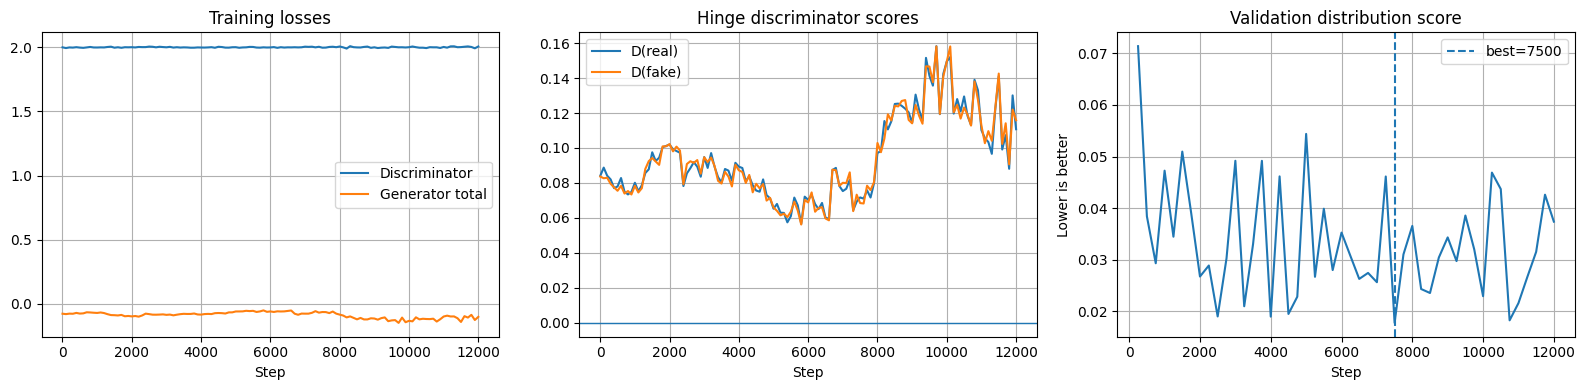

In [11]:
# 11. Training diagnostics

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(
    history["step"],
    history["D_loss"],
    label="Discriminator",
)
axes[0].plot(
    history["step"],
    history["G_loss"],
    label="Generator total",
)
axes[0].set_title("Training losses")
axes[0].set_xlabel("Step")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    history["step"],
    history["D_real_score"],
    label="D(real)",
)
axes[1].plot(
    history["step"],
    history["D_fake_score"],
    label="D(fake)",
)
axes[1].axhline(0.0, linewidth=1)
axes[1].set_title("Hinge discriminator scores")
axes[1].set_xlabel("Step")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(
    history["val_step"],
    history["val_score"],
)
axes[2].axvline(
    best_step,
    linestyle="--",
    label=f"best={best_step}",
)
axes[2].set_title("Validation distribution score")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Lower is better")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 12. IQ Distribution

Compare real and generated IQ samples on the same axes.


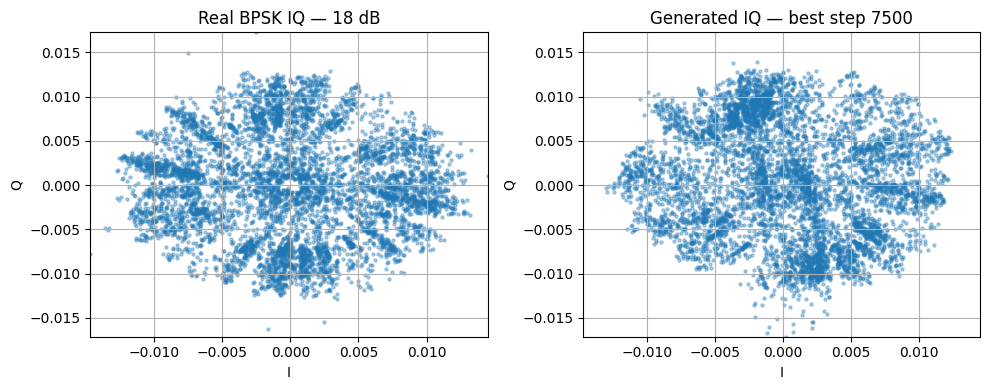

In [12]:
# 12. Real vs generated IQ distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

n_plot = min(50, len(real_raw))

real_i = real_raw[:n_plot, :, 0].reshape(-1)
real_q = real_raw[:n_plot, :, 1].reshape(-1)

fake_i = fake_raw[:n_plot, :, 0].reshape(-1)
fake_q = fake_raw[:n_plot, :, 1].reshape(-1)

# Shared axis limits are essential for a fair visual comparison.
i_min = min(real_i.min(), fake_i.min())
i_max = max(real_i.max(), fake_i.max())
q_min = min(real_q.min(), fake_q.min())
q_max = max(real_q.max(), fake_q.max())

axes[0].scatter(
    real_i,
    real_q,
    s=5,
    alpha=0.35,
)
axes[0].set_title("Real BPSK IQ — 18 dB")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Q")
axes[0].set_xlim(i_min, i_max)
axes[0].set_ylim(q_min, q_max)
axes[0].grid(True)

axes[1].scatter(
    fake_i,
    fake_q,
    s=5,
    alpha=0.35,
)
axes[1].set_title(
    f"Generated IQ — best step {best_step}"
)
axes[1].set_xlabel("I")
axes[1].set_ylabel("Q")
axes[1].set_xlim(i_min, i_max)
axes[1].set_ylim(q_min, q_max)
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 13. PSD Comparison

Compare the average normalized power spectrum of real and generated IQ data.


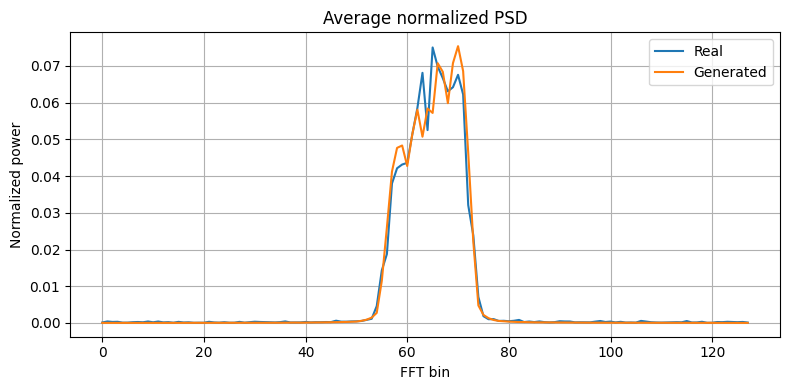

In [13]:
# 13. Power spectral density comparison

def numpy_average_psd(x):
    complex_iq = (
        x[:, :, 0]
        + 1j * x[:, :, 1]
    )

    spectrum = np.fft.fftshift(
        np.fft.fft(
            complex_iq,
            axis=1,
        ),
        axes=1,
    )

    power = np.abs(spectrum) ** 2
    power = power.mean(axis=0)
    power = power / (power.sum() + 1e-12)

    return power


real_psd = numpy_average_psd(real_raw)
fake_psd = numpy_average_psd(fake_raw)

plt.figure(figsize=(8, 4))
plt.plot(real_psd, label="Real")
plt.plot(fake_psd, label="Generated")
plt.title("Average normalized PSD")
plt.xlabel("FFT bin")
plt.ylabel("Normalized power")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 14. Constellation Geometry

Inspect line-likeness and orientation for real and generated BPSK sequences.


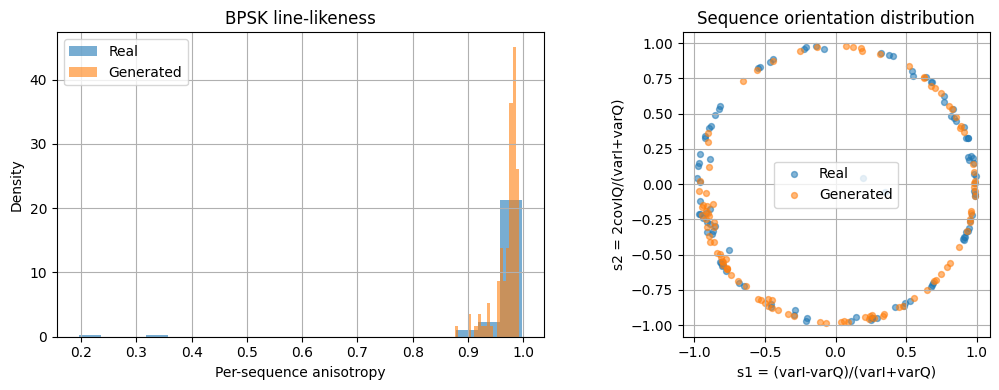

In [14]:
# 14. Sequence-level geometry diagnostics

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(
    real_geom[:, 5],
    bins=20,
    alpha=0.6,
    density=True,
    label="Real",
)
axes[0].hist(
    fake_geom[:, 5],
    bins=20,
    alpha=0.6,
    density=True,
    label="Generated",
)
axes[0].set_xlabel("Per-sequence anisotropy")
axes[0].set_ylabel("Density")
axes[0].set_title("BPSK line-likeness")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(
    real_geom[:, 3],
    real_geom[:, 4],
    s=18,
    alpha=0.55,
    label="Real",
)
axes[1].scatter(
    fake_geom[:, 3],
    fake_geom[:, 4],
    s=18,
    alpha=0.55,
    label="Generated",
)
axes[1].set_xlabel("s1 = (varI-varQ)/(varI+varQ)")
axes[1].set_ylabel("s2 = 2covIQ/(varI+varQ)")
axes[1].set_title("Sequence orientation distribution")
axes[1].set_aspect("equal", adjustable="box")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 15. Attention Map

Visualize the learned temporal attention weights of the generator.


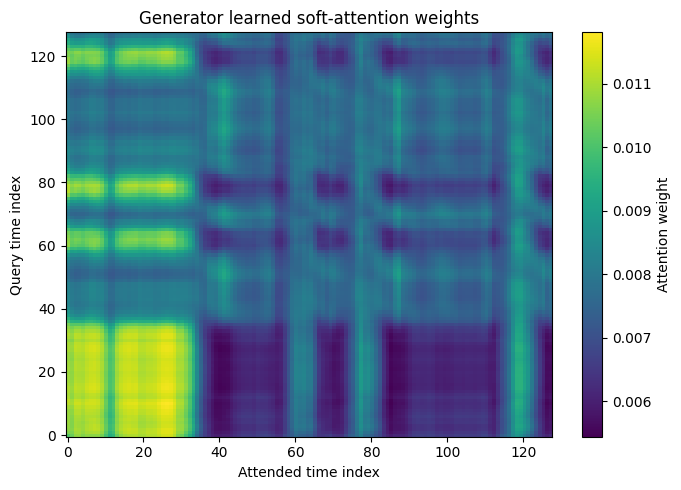

In [15]:
# 15. Generator attention map

with torch.no_grad():
    z = sample_latent(1, device)
    _, attention = G(
        z,
        return_attention=True,
    )

attention = attention[0].cpu().numpy()

plt.figure(figsize=(7, 5))
plt.imshow(
    attention,
    aspect="auto",
    origin="lower",
)
plt.xlabel("Attended time index")
plt.ylabel("Query time index")
plt.title("Generator learned soft-attention weights")
plt.colorbar(label="Attention weight")
plt.tight_layout()
plt.show()

## 16. Save the Best Model

Save the best generator checkpoint together with its configuration.


In [16]:
# 16. Save BEST checkpoint

MODEL_DIR = Path(
    "/content/drive/MyDrive/GenTWIN_Project/models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SAVE_PATH = (
    MODEL_DIR
    / "softgan_bpsk_snr18_geometry_aware_best.pt"
)

torch.save(
    {
        "generator_state_dict": G.state_dict(),
        "best_step": best_step,
        "best_validation_score": best_val_score,

        "seq_len": SEQ_LEN,
        "global_noise_dim": GLOBAL_NOISE_DIM,
        "local_noise_dim": LOCAL_NOISE_DIM,

        "batch_size": BATCH_SIZE,
        "lr_G": LR_G,
        "lr_D": LR_D,
        "adam_betas": ADAM_BETAS,
        "train_steps": TRAIN_STEPS,
        "g_updates_per_step": G_UPDATES_PER_STEP,

        "r1_gamma": R1_GAMMA,
        "r1_interval": R1_INTERVAL,
        "feature_match_weight": FEATURE_MATCH_WEIGHT,
        "psd_weight": PSD_WEIGHT,
        "geometry_mmd_weight": GEOMETRY_MMD_WEIGHT,
        "geometry_warmup_steps": GEOMETRY_WARMUP_STEPS,
        "geometry_checkpoint_weight": GEOMETRY_CHECKPOINT_WEIGHT,
        "geometry_reference_floor": geometry_reference_floor,
        "geometry_feature_mean": GEOM_MEAN.detach().cpu(),
        "geometry_feature_std": GEOM_STD.detach().cpu(),

        "normalization_clip": NORM_CLIP,
        "train_mean": train_mean,
        "train_std": train_std,

        "history": history,
        "seed": SEED,
        "dataset_dir": str(DATA_DIR),
    },
    SAVE_PATH,
)

print("Saved BEST generator checkpoint:")
print(SAVE_PATH)

Saved BEST generator checkpoint:
/content/drive/MyDrive/GenTWIN_Project/models/softgan_bpsk_snr18_geometry_aware_best.pt


## 17. Discriminative Score

Train a post-hoc LSTM classifier to distinguish real and generated sequences.


In [17]:
# 17. Post-hoc two-layer LSTM discriminative score

class PostHocDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
            dropout=0.1,
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.fc(h[:, -1, :])


@torch.no_grad()
def generate_sequences(generator, n):
    generator.eval()

    chunks = []

    remaining = n

    while remaining > 0:
        b = min(256, remaining)
        z = sample_latent(b, device)
        chunks.append(generator(z).cpu())
        remaining -= b

    return torch.cat(chunks, dim=0)


# Train classifier on real training data vs generated training-sized data.
fake_for_disc_train = generate_sequences(
    G,
    len(X_train_seq),
)

real_for_disc_train = torch.from_numpy(
    X_train_seq
)

X_disc_train = torch.cat(
    [real_for_disc_train, fake_for_disc_train],
    dim=0,
)

y_disc_train = torch.cat(
    [
        torch.ones(len(real_for_disc_train), 1),
        torch.zeros(len(fake_for_disc_train), 1),
    ],
    dim=0,
)

# Test on completely held-out real test data and fresh generated data.
fake_for_disc_test = generate_sequences(
    G,
    len(X_test_seq),
)

real_for_disc_test = torch.from_numpy(
    X_test_seq
)

X_disc_test = torch.cat(
    [real_for_disc_test, fake_for_disc_test],
    dim=0,
)

y_disc_test = torch.cat(
    [
        torch.ones(len(real_for_disc_test), 1),
        torch.zeros(len(fake_for_disc_test), 1),
    ],
    dim=0,
)

train_ds = TensorDataset(
    X_disc_train,
    y_disc_train,
)

disc_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
)

posthoc = PostHocDiscriminator().to(device)

posthoc_optimizer = torch.optim.Adam(
    posthoc.parameters(),
    lr=1e-3,
)

posthoc_criterion = nn.BCEWithLogitsLoss()

posthoc.train()

for epoch in range(30):

    for xb, yb in disc_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        posthoc_optimizer.zero_grad(
            set_to_none=True
        )

        logits = posthoc(xb)
        loss = posthoc_criterion(
            logits,
            yb,
        )

        loss.backward()
        posthoc_optimizer.step()

posthoc.eval()

with torch.no_grad():
    logits = posthoc(
        X_disc_test.to(device)
    )

    predictions = (
        torch.sigmoid(logits) >= 0.5
    ).float().cpu()

    accuracy = (
        predictions == y_disc_test
    ).float().mean().item()

# TimeGAN-style discriminative score:
# 0 is ideal because classifier accuracy is then 50%.
discriminative_score = abs(
    accuracy - 0.5
)

print(
    "Post-hoc classifier accuracy:",
    f"{accuracy:.4f}",
)

print(
    "Discriminative score |acc-0.5|:",
    f"{discriminative_score:.4f}",
)

Post-hoc classifier accuracy: 0.5100
Discriminative score |acc-0.5|: 0.0100


## 18. Metric Utilities

Prepare fresh real and generated test sets for the remaining metrics.


In [18]:
# 18. Utilities for paper-style metrics

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.optimize import linear_sum_assignment
from scipy.linalg import sqrtm


def generate_normalized_sequences(generator, n, batch_size=256):
    generator.eval()

    chunks = []
    remaining = n

    with torch.no_grad():
        while remaining > 0:
            b = min(batch_size, remaining)
            z = sample_latent(b, device)
            chunks.append(generator(z).cpu())
            remaining -= b

    return torch.cat(chunks, dim=0)


# Use fresh generated samples for the evaluation.
real_test_metric = torch.from_numpy(
    X_test_seq
).float()

fake_test_metric = generate_normalized_sequences(
    G,
    len(X_test_seq),
).float()

print("Real metric set:", tuple(real_test_metric.shape))
print("Fake metric set:", tuple(fake_test_metric.shape))

Real metric set: (100, 128, 2)
Fake metric set: (100, 128, 2)


## 19. NRMSE

Compute assignment-based normalized RMSE between real and generated sequences.


In [19]:
# 19. NRMSE — optimal-assignment normalized RMSE

def assignment_nrmse(real_seq, fake_seq):
    """
    Distribution-aware NRMSE for unpaired generative samples.

    1. Flatten each IQ sequence.
    2. Build pairwise RMSE cost matrix.
    3. Use Hungarian optimal assignment.
    4. Normalize matched RMSE by RMS magnitude of the real data.

    Lower is better.
    """

    real = real_seq.numpy()
    fake = fake_seq.numpy()

    n = min(len(real), len(fake))

    real = real[:n].reshape(n, -1)
    fake = fake[:n].reshape(n, -1)

    # Pairwise MSE/RMSE cost matrix
    diff = real[:, None, :] - fake[None, :, :]
    pairwise_rmse = np.sqrt(
        np.mean(diff ** 2, axis=2)
    )

    row_idx, col_idx = linear_sum_assignment(
        pairwise_rmse
    )

    matched_rmse = pairwise_rmse[
        row_idx,
        col_idx,
    ].mean()

    real_rms = np.sqrt(
        np.mean(real ** 2)
    )

    nrmse = matched_rmse / (
        real_rms + 1e-12
    )

    return float(nrmse), float(matched_rmse), float(real_rms)


nrmse, matched_rmse, real_rms = assignment_nrmse(
    real_test_metric,
    fake_test_metric,
)

print("NRMSE:", f"{nrmse:.6f}")
print("Matched RMSE:", f"{matched_rmse:.6f}")
print("Real RMS normalization:", f"{real_rms:.6f}")

NRMSE: 1.052951
Matched RMSE: 0.263934
Real RMS normalization: 0.250661


## 20. Context Encoder

Train a two-layer LSTM context encoder on real training sequences.


In [20]:
# 20. Train real-data LSTM context encoder

class ContextEncoder(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.1,
        )

        self.predictor = nn.Linear(
            hidden_size,
            2,
        )

    def forward(self, x, return_embedding=False):
        h, _ = self.lstm(x)

        if return_embedding:
            # Mean temporal context embedding
            return h.mean(dim=1)

        # Predict x[t+1] from hidden state at t
        return self.predictor(h[:, :-1, :])


context_model = ContextEncoder(
    hidden_size=64
).to(device)

context_optimizer = torch.optim.Adam(
    context_model.parameters(),
    lr=1e-3,
)

context_criterion = nn.L1Loss()

context_train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train_seq).float()
    ),
    batch_size=64,
    shuffle=True,
)

context_model.train()

CONTEXT_EPOCHS = 40

for epoch in range(CONTEXT_EPOCHS):

    epoch_loss = 0.0

    for (xb,) in context_train_loader:

        xb = xb.to(device)

        context_optimizer.zero_grad(
            set_to_none=True
        )

        pred = context_model(xb)
        target = xb[:, 1:, :]

        loss = context_criterion(
            pred,
            target,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            context_model.parameters(),
            max_norm=5.0,
        )

        context_optimizer.step()

        epoch_loss += loss.item() * len(xb)

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
        or epoch == CONTEXT_EPOCHS - 1
    ):
        print(
            f"Context epoch {epoch + 1:02d}/{CONTEXT_EPOCHS} | "
            f"MAE={epoch_loss / len(X_train_seq):.6f}"
        )

Context epoch 01/40 | MAE=0.205332
Context epoch 10/40 | MAE=0.038420
Context epoch 20/40 | MAE=0.026245
Context epoch 30/40 | MAE=0.020891
Context epoch 40/40 | MAE=0.018241


## 21. Context FID

Compute Fréchet distance in the learned LSTM context space.


In [21]:
# 21. Context FID

def get_context_embeddings(model, sequences, batch_size=128):
    model.eval()

    loader = DataLoader(
        TensorDataset(sequences),
        batch_size=batch_size,
        shuffle=False,
    )

    embeddings = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)

            emb = model(
                xb,
                return_embedding=True,
            )

            embeddings.append(
                emb.cpu().numpy()
            )

    return np.concatenate(
        embeddings,
        axis=0,
    )


def frechet_distance(features_real, features_fake, eps=1e-6):
    """
    Standard Fréchet distance between two Gaussian feature distributions.
    Lower is better.
    """

    mu_r = np.mean(
        features_real,
        axis=0,
    )

    mu_f = np.mean(
        features_fake,
        axis=0,
    )

    cov_r = np.cov(
        features_real,
        rowvar=False,
    )

    cov_f = np.cov(
        features_fake,
        rowvar=False,
    )

    # Numerical stabilization
    cov_r = cov_r + eps * np.eye(cov_r.shape[0])
    cov_f = cov_f + eps * np.eye(cov_f.shape[0])

    mean_term = np.sum(
        (mu_r - mu_f) ** 2
    )

    cov_sqrt = sqrtm(
        cov_r @ cov_f
    )

    if np.iscomplexobj(cov_sqrt):
        cov_sqrt = cov_sqrt.real

    fid = (
        mean_term
        + np.trace(
            cov_r
            + cov_f
            - 2.0 * cov_sqrt
        )
    )

    return float(np.real(fid))


real_context = get_context_embeddings(
    context_model,
    real_test_metric,
)

fake_context = get_context_embeddings(
    context_model,
    fake_test_metric,
)

context_fid = frechet_distance(
    real_context,
    fake_context,
)

print("Context FID:", f"{context_fid:.6f}")
print("Context embedding dimension:", real_context.shape[1])

Context FID: 0.000844
Context embedding dimension: 64


## 22. Predictive Score

Train on generated sequences and evaluate next-step prediction on real test data.


In [22]:
# 22. Predictive Score — train on synthetic, test on real

class PostHocPredictor(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.1,
        )

        self.fc = nn.Linear(
            hidden_size,
            2,
        )

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.fc(
            h[:, :-1, :]
        )


# Generate a synthetic training set with the same size as the real training set.
fake_predictive_train = generate_normalized_sequences(
    G,
    len(X_train_seq),
)

predictor_train_loader = DataLoader(
    TensorDataset(
        fake_predictive_train
    ),
    batch_size=64,
    shuffle=True,
)

predictor = PostHocPredictor(
    hidden_size=32
).to(device)

predictor_optimizer = torch.optim.Adam(
    predictor.parameters(),
    lr=1e-3,
)

predictor_criterion = nn.L1Loss()

PREDICTOR_EPOCHS = 40

predictor.train()

for epoch in range(PREDICTOR_EPOCHS):

    total_loss = 0.0

    for (xb,) in predictor_train_loader:

        xb = xb.to(device)

        predictor_optimizer.zero_grad(
            set_to_none=True
        )

        pred = predictor(xb)
        target = xb[:, 1:, :]

        loss = predictor_criterion(
            pred,
            target,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            predictor.parameters(),
            max_norm=5.0,
        )

        predictor_optimizer.step()

        total_loss += loss.item() * len(xb)

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
        or epoch == PREDICTOR_EPOCHS - 1
    ):
        print(
            f"Predictor epoch {epoch + 1:02d}/{PREDICTOR_EPOCHS} | "
            f"synthetic MAE={total_loss / len(fake_predictive_train):.6f}"
        )


# Evaluate only on held-out REAL test data.
predictor.eval()

with torch.no_grad():

    real_test_device = real_test_metric.to(
        device
    )

    real_pred = predictor(
        real_test_device
    )

    real_target = real_test_device[
        :,
        1:,
        :,
    ]

    predictive_score = F.l1_loss(
        real_pred,
        real_target,
    ).item()

print(
    "Predictive Score (real-test MAE):",
    f"{predictive_score:.6f}",
)

Predictor epoch 01/40 | synthetic MAE=0.217725
Predictor epoch 10/40 | synthetic MAE=0.067553
Predictor epoch 20/40 | synthetic MAE=0.039137
Predictor epoch 30/40 | synthetic MAE=0.030835
Predictor epoch 40/40 | synthetic MAE=0.025997
Predictive Score (real-test MAE): 0.021592


## 23. Final Metrics

Print the final evaluation metrics for the trained SoftGAN model.


In [23]:
# 23. Final paper-style metric summary

# The discriminative score should already exist from the previous cell.
# If the variable is unavailable because cells were run selectively,
# show NaN rather than silently recomputing a different version.
disc_value = (
    float(discriminative_score)
    if "discriminative_score" in globals()
    else float("nan")
)

print("=" * 58)
print("SOFTGAN — RADIOML BPSK 18 dB — PAPER-STYLE METRICS")
print("=" * 58)
print(f"NRMSE                : {nrmse:.6f}")
print(f"Context FID          : {context_fid:.6f}")
print(f"Discriminative Score : {disc_value:.6f}")
print(f"Predictive Score     : {predictive_score:.6f}")
print("-" * 58)
print("Gen-TWIN paper reference at sequence length 128:")
print("NRMSE                : 0.23 ± 0.02")
print("Context FID          : 0.15 ± 0.01")
print("Discriminative Score : 0.017 ± 0.02")
print("Predictive Score     : 0.016 ± 0.004")
print("=" * 58)

SOFTGAN — RADIOML BPSK 18 dB — PAPER-STYLE METRICS
NRMSE                : 1.052951
Context FID          : 0.000844
Discriminative Score : 0.010000
Predictive Score     : 0.021592
----------------------------------------------------------
Gen-TWIN paper reference at sequence length 128:
NRMSE                : 0.23 ± 0.02
Context FID          : 0.15 ± 0.01
Discriminative Score : 0.017 ± 0.02
Predictive Score     : 0.016 ± 0.004


## Reference

O. T. Basaran *et al.*, **“Gen-TWIN: Generative-AI-Enabled Digital Twin for Open Radio Access Networks,”** IEEE INFOCOM Workshops, 2025. DOI: 10.1109/INFOCOMWKSHPS65812.2025.11152803.
